### Protein Bioinformatics - Challenge Project
### Author: Drew Fatone

Protein of interest: Human Lysozyme


 Sequence PDB ID: 1REX
 https://www.rcsb.org/structure/1REX



### 1. Describe how you can potentially calculate the phi and psi dihedral angles, as defined by the IUPAC standards, using the coordinates of the backbone atoms from the PDB file. Specifically, use figures, equations, and code to demonstrate a viable calculation and validation strategy.


According to the IUPAC, phi ($\phi$) is the angle decribing the rotational angle about the $N-C_\alpha$ bond and the psi ($\psi$) angle describes the rotational angle about the $C_\alpha-C$ bond (1969).

Each bond can be described by 4 atoms:
$$
\phi = C_(i-1) , N_i, C_i^\alpha, C_i
$$
$$
\psi = N_i, C_i^\alpha, C_i, N_(i+1)  
$$

Since we have the coordinates of each of these atoms within our PDB file, we can use these to calculate the phi and psi angle for each residue.

We can assume that within each group of four atoms there are two planes created, one containing the first three atoms and one containing the last three atoms.



Since I am not great with math, and the concept of creating two planes and calculating the angle in between from cartesian coordinates is foreign to me, I have consulted ChatGPT to help me design and understand series of calculations to determine the phi and psi dihedral angles from the cartesian coordinates given in the PDB file. (OpenAI, 2023)

The first step to calculating the dihedral angles is to turn our cartesian coordinates into planes so we can measure the angles in between. To create planes, we must first create vectors from our coordinates. This done by subtracting one coordinate from the other:

$$
Vector A(C_(i-1) , N_i) = C_(i-1)(x,y,z) - N_i(x,y,z)
$$

$$
Vector B(N_i,C_i^\alpha) = N_i(x,y,z) - C_i^\alpha(x,y,z)
$$

We repeat this for each pair of atoms in the bond, 4 atoms should give us three vectors, and then we pair up the vectors to create 2 planes by taking the cross product of these vectors. This cross product will represent the normal vector that is perpendicular to the plane that contains all three atoms.

Ex.
$$
Plane A = Vector A \times Vector B 
$$

We will repeat this process again with our other pair of vectors (B & C) to get our other plane, and now we will be able to calculate the angle in between.

Now that we have two plane vectors, we can calculate the magnitude of the two normal vectors using the equation:

$$
Magnitude(|A|) = \sqrt{x^2 + y^2 + z^2}
$$

We can also calculate the dot product of the two normal vectors using the equation:

$$
Dot Product (A \cdot B) = x_A * x_B + y_A * y_B + z_A * z_B
$$

from here we can  now calculate the angle using the equation:

$$
(A \cdot B) = |A| * |B| * cos(\theta)
$$

we can rearrange this to solve for $\theta$:
$$
\theta = arccos(\frac{(A \cdot B)}{|A|*|B|})
$$

and then we can convert to degrees by multiplying the above result by 180/$\pi$




There are a few assumptions I will make as I adjust these formulas to fit my code. First off, I believe within each residue, there are 3 planes used to calculate the $\phi$ and $\psi$ angles, of which, the middle plane that contains the $(N_i,C_i^\alpha,C_i)$ atoms is the same for both angles so I will save some time by calculating all three planes at the same time and then calculate the separate angles. The second assumption is that I need to adjust each of my angles by subtracting 90 degrees from them to get them into a (-180,180) degree range. This adjustment is to move the angles into a range to allow for classification.

In [1]:
#import the pdb file and extract the atomic coordinates
file = "C:/Temp/1rex.cif"
atoms = []
for line in open(file):
    if line.startswith("ATOM"):
        atoms += [line.split()]

In [2]:
#This method will take input in the form of a list of PDB "ATOM" lines, split by whitespace
#The method will extract the backbone atoms and their coordinates and return them in a residue specific list to be used for angle calculations
#
#@author: Drew Fatone
def extract_backbone(_atoms):
    _residue_bb = []
    curr_res = 0
    for _atom in _atoms:
        residue_num = int(_atom[8])
        if residue_num > curr_res: #we have a new residue, move to next index
            index = residue_num -1
            curr_res = residue_num
            _residue_bb += [[curr_res]]
        #check for backbone atoms and extract coordinates
        if _atom[3] == 'N' or _atom[3] == 'CA' or _atom[3] == 'C':
            _residue_bb[index] += [(float(_atom[10]),float(_atom[11]),float(_atom[12]))]
    return _residue_bb


In [3]:
res_bb = extract_backbone(atoms)

In [4]:
#sanity check
res_bb[:5]

[[1,
  (1.251, 19.636, 22.152),
  (1.899, 20.606, 21.229),
  (3.168, 20.004, 20.624)],
 [2,
  (3.384, 20.212, 19.329),
  (4.597, 19.736, 18.678),
  (5.389, 21.024, 18.429)],
 [3,
  (6.521, 21.159, 19.117),
  (7.373, 22.338, 18.986),
  (8.142, 22.331, 17.689)],
 [4, (8.479, 23.52, 17.209), (9.334, 23.632, 16.04), (10.72, 23.618, 16.696)],
 [5,
  (11.734, 23.199, 15.95),
  (13.093, 23.09, 16.478),
  (13.62, 24.303, 17.254)]]

In [ ]:
import numpy as np

#this method will take input in the form of a residue_backbone list in the format [[residue_num, N coordinates, CA coordinates, C coordinates]]
#and will return a list of calculated phi and psi dihedral angles
#
#@author: Drew Fatone
def calculate_angles(_residues_bb):
    no_phi = False
    no_psi = False
    _residue_angles = []

    for index in range(len(_residues_bb)):
        #grab the atomic coordinates of the important atoms for calculating phi & psi angles
        if index <= 0: #first residue has no previous residue to calculate phi angle
            c_prev = None
            no_phi = True
        else:
            c_prev =np.array(_residues_bb[index-1][3])
        n_i = np.array(_residues_bb[index][1])
        ca_i = np.array(_residues_bb[index][2])
        c_i = np.array(_residues_bb[index][3])
        if index == (len(_residues_bb)-1):# last residue will have no next residue, therfore no psi angle
            n_next = None
            no_psi = True
        else:
            n_next = _residues_bb[index+1][1]


        #for each residue, we will need to create 3 planes
        #for each plane, we will use three atoms
        #Plane A (C-1, N, CA)
        if no_phi:
            print(f"Cannot calculate phi angle for first residue at index {index}")
        else:
            #to create this plane we will use two vectors
            #Vector A (C-1, N)
            vector_a = c_prev - n_i
            #Vector B (N,CA)
            vector_b = ca_i - n_i
            plane_a = np.cross(vector_a,vector_b)

        #Plane B (N, CA, C)
        #Vector C (N, CA)
        vector_c = n_i - ca_i
        #Vector D (CA, C)
        vector_d = c_i - ca_i
        plane_b = np.cross(vector_c,vector_d)
        
        #Plane C (CA, C, N+1)
        if no_psi:
            print(f"Cannot calculate psi angle for last residue at index {index}")
        else:
            #to create this plane we will use two vectors
            #Vector E (CA,C)
            vector_e = ca_i - c_i
            #Vector F (C, N+1)
            vector_f = n_next - c_i
            plane_c = np.cross(vector_e,vector_f)

        #now we have 3 plane vectors, we can use these to calculate the phi and psi dihedral angles
        #calculate magnitudes
        if not no_phi:
            magnitude_a = np.sqrt(np.sum(plane_a*plane_a)) #check this for errors 10/29/2025
        magnitude_b = np.sqrt(np.sum(plane_b*plane_b))
        if not no_psi:
            magnitude_c = np.sqrt(np.sum(plane_c*plane_c))

        #Phi angle ( Plane A, Plane B)
        if no_phi:
           phi_deg = None
           no_phi = False
        else:
            phi_angle = np.arccos((np.dot(plane_a,plane_b))/(magnitude_a * magnitude_b))
            #convert to degrees
            phi_deg = (phi_angle * (180/np.pi)) -90 #adjust angle by 90 degrees
        
        #Psi angle ( Plane B, Plane C)
        if no_psi:
            psi_deg = None
            no_psi = False
        else:
            psi_angle = np.arccos((np.dot(plane_b,plane_c))/(magnitude_b * magnitude_c))
            #convert to degrees
            psi_deg = (psi_angle * (180/np.pi)) -90 #adjust angle by 90 degrees
        #bundle angles
        _residue_angles += [[phi_deg, psi_deg]]
    return _residue_angles
        


In [6]:
angles = calculate_angles(res_bb)

Cannot calculate phi angle for first residue at index 0
Cannot calculate psi angle for last residue at index 129


In [7]:
#sanity check
angles[:10]

[[None, 47.80893925060633],
 [17.862979149542824, 23.12786754377916],
 [-15.366296316304684, 62.75517168268618],
 [-1.9483385441317296, 64.93311806421713],
 [-41.87073746025679, -29.01513971308257],
 [-21.200759428895083, -60.47074042693316],
 [-28.709788952146788, -46.12441534316267],
 [-22.453577741349562, -48.0154409021025],
 [-31.493557285265766, -44.38014083164062],
 [-22.10094472975048, -54.92126343990228]]

### 2. Describe a strategy for assigning secondary structure based on phi and psi angles. You should assign the secondary structure type for each residue, given the backbone coordinates of the PDB file. The classification should be based on the phi and psi angles of the residue from the steps determined in Question 1; you may use the idea of a Ramachandran plot to define your assignment criteria. Here, a classification in three groups (alpha, beta, other) would be sufficient.  Implement a program that can assign the secondary structure type for each residue given the backbone coordinates of a PDB file. Show annotated program code and relevant outputs from the code.


One simple strategy to assign secondary structure on a residue specific basis, would be to classify each residue based on the values of the phi and psi angles I have calculated.
The simplest way to achieve this classification would be to use conditionals, if the phi angle is in this range of values while the psi angle is in this range of values, that would signify one classification of secondary structure. I will use ranges for phi and psi dihedral angles that are roughly based on a ramachandran plot, which attempts to classify secondary structures based on these two criteria.

For each group, alpha, beta, and other, I identified regions on a Ramachandran plot (shown below) that corresponded to alpha helices, and beta-sheets:


The alpha-helix will be defined by $\phi$ and $\psi$ angles in the ranges:
$$
 ((-150<=\phi<=-60) \; and \; (-60<\psi<-45)) \; or \; ((50<=\phi<=60)\; and\; (10<=\psi<=75)):
$$

And the beta-sheet will be defined by $\phi$ and $\psi$ angles in the range:
$$
(-150<=\phi<=-110) \; and \; (110<=\psi<=170):
$$

these values are roughly based on this plot by Ramachandran et al. (1963):

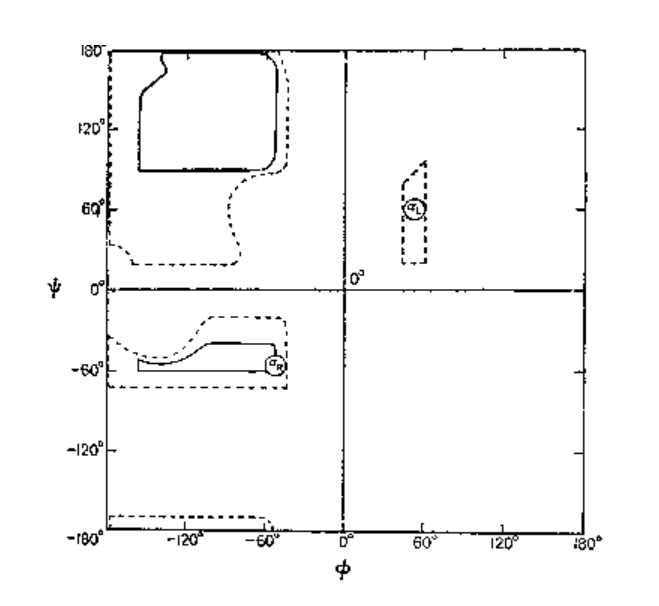


Note: I needed to adjust my angles, to fit into the classification ranges of this Ramachandran plot by subtracting 90 degrees from each angle. I believe this could be correcting a potential error in my angle calculations. Without this angle adjustment, my calculated angles for both phi and psi are all in the range of $0<\theta<180$, which could potentially classify left-handed alpha-helices, but would give no information on beta sheets.

In [8]:
#This method will classify the secondary structure of protein residues when given input in the form of a list of phi and psi angles for each residue.
#A list of classifications for each residue will be returned
#
#@author: Drew Fatone
def classify_angles(_res_angles):
    _classified_residues = []
    for residue in _res_angles:
        _phi = residue[0]
        _psi = residue[1]

        #classify using simple conditionals derived from Ramachandran plot       
        if (_phi == None) or (_psi == None): #first or last residue
            _classified_residues += ['Other']
        else:
            #alpha-helix
            if ((-150<=_phi<=-60) and (-60<_psi<-45)) or ((50<=_phi<=60) and (10<=_psi<=75)):
                _classified_residues += ['Alpha']
            #beta-sheet
            if (-150<=_phi<=-110) and (110<=_psi<=170):
                _classified_residues += ['Beta']
            else:
                _classified_residues += ['Other']

    return _classified_residues


In [9]:
classified_residues = classify_angles(angles)

In [10]:
#print out identified secondary structures
for ix in range(len(classified_residues)):
    if classified_residues[ix] != 'Other':
        print(f"Residue: {ix+1} Classification: {classified_residues[ix]}")

Residue: 43 Classification: Alpha
Residue: 45 Classification: Alpha


### 3. What types of secondary structures do you find in this protein?

Unfortunately, my program did not identify any secondary structures in this protein, besides two residues that it classified as alpha helices. This performance was rather abysmal. but leaves room for improvement. This must be indicitave of an error in my angle calculations.


### 4. Take a detailed look at the assignment of secondary structure by your program. Inspect your protein through the molecular visualization software of your choice. Specifically, consider the length of the secondary structure elements. You may also compare your secondary structure assignment to the output of the DSSP.  Show images and analysis of all of your secondary structure exploration. Do you find common supersecondary structures? Motifs? Domains? Patches, pockets, or other surface properties? How can your analysis be linked to the function of the protein?


My program only identified two secondary structures based on the phi and psi dihedral angles, alpha-helices at residues 43 and 45.

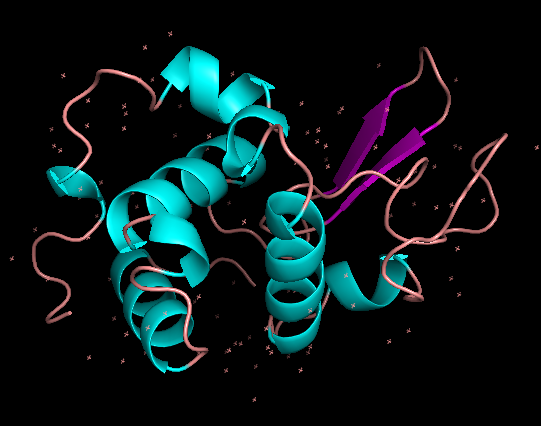

In the above image, generated from the 1REX.cif file using PyMol, we can see the secondary structures of the protein represented by a cartoon and also colored (Cyan=alpha-helix, Magenta = beta-sheet) Obviously my program failed to classify the entirety of these secondary structures.

However, if we look at the sequence of the protein in PyMol colored by secondary structure (below), we can see that the two residues my program classified as alpha-helix are part of a secondary structure, but they are classified as a beta-sheet.

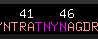

To me this is a clear indicator that something in my calculations is off, and my secondary structure prediction is nowhere near where it should be for actual use in the field. My program will not be useful for analysis until I can correct the errors in my calculations or classifications that are resulting in poor performance.

### 5. Show an example of a secondary structure element assigned by the program that seems incorrect to you. Discuss the quality of your results and possible problems. Suggest improvements to your assignment strategy (to overcome these problems). Be specific regarding the parameters used, statistical approaches, and evaluation criteria.


My entire secondary structure assignment seems to be innacurate, as my program failed to classify any structures besides two residues, which it classified incorrectly. I believe the main cause of this issue to be a problem with the way that the phi and psi angles are calculated, but I am not sure what the exact issue is. I believe the quality of these results to be extremely poor, but this means that there is a lot of room for improvement. First, I would try to figure out the exact issue with my angle calculation, so I could make sure that my classification method will be using the properly calculated angles for classification. The next way I would improve my strategy would be to build better definitions of each of my classification types. If I could find specific values for the classification ranges, to either widen or narrow the ranges, I believe that could help with better classification per residue. Another possible improvement to the secondary structure prediction strategy could be to take a machine learning approach to classify the secondary structure based on the dihedral angles. If we trained a machine learning model on proteins with known phi and psi angles and known secondary structures, it could possibly come up with better classification parameters than the simple conditionals used in my strategy.

### References

IUPAC, Abbreviations and symbols for the description of the conformation of polypeptide chains. Polypeptide Conformations 3. Tentative Rules (1969). 
    https://iupac.qmul.ac.uk/misc/noGreek/ppep3.html 
    
OpenAI. (2023). ChatGPT (Sep 23 version) [Large language model].
    chat.openai.com

Ramachandran, G. N., Ramakrishnan, C., and Sasisekharan, V. (1963), J. Mol. Biol. 7, 95.



## Appendix on AI-usage

While I did not use AI to produce any code for this project, I did use it to outline the process of calculating the dihedral angles from cartesian coordinates. I started by asking exactly "How can I calculate dihedral angles from cartesian coordinates?" and was suggested the above method of converting the coordinates into vectors, taking the cross products of those resulting vectors to generate normal vectors for planes, then using the dot product of those plane vectors to calculate the angle using the arccosine. I compared this method to other websites and YouTube videos that suggested similar approaches to create planes from the coordinates and then to calculate angles and the methods appeared to agree. I then asked ChatGPT to explain each step to me in a little bit more detail so I could understand what taking the cross product and dot products would actually do, as I had heard of these but did not understand what they do exactly or how. I was also confused on how we converted cartesian  coordinates into vectors and the AI helped to explain how by subtracting one point from another I was creating a distance vector pointing from one coordinate to the other. This greatly helped me understand the mathematic concepts behind the calculations of the dihedral angles that I was unsure about, and it provided me a series of calculations to find the dihedral angles. Once I had the calculations figured out, it was up to me to implement them in the code.